In [57]:
import pandas as pd
import numpy as np

# ==============================
# Weekly backtest (~3 months ahead)
# ==============================

HORIZON_WEEKS = 13  # about 3 months

weekly_df = pd.read_csv("data/processed/weekly_beer_data.csv", parse_dates=["week"])

# Normalize beer names (treat aliases as the same beer)
BEER_ALIAS_MAP = {
    "Hoop US Lager": "Hoop Lager",
    "Hoop Lager": "Hoop Lager",
    "Hoop Kaper North East IPA": "Hoop Kaper Tropical IPA",
    "Hoop Kaper Tropical IPA": "Hoop Kaper Tropical IPA",
    "Hoop Bleke Nelis": "Hoop Bleke Nelis",
}
weekly_df["beer"] = weekly_df["beer"].replace(BEER_ALIAS_MAP)

FOCUS_BEERS = ["Hoop Bleke Nelis", "Hoop Lager", "Hoop Kaper Tropical IPA"]

# Pre-compute seasonal monthly average liters per beer (all containers)
weekly_df["month"] = weekly_df["week"].dt.month
seasonal_monthly_avg = (
    weekly_df.groupby(["beer", "month"], as_index=False)["liters"].mean()
    .rename(columns={"liters": "month_seasonal_avg"})
)

# Pick a series (for experimentation)
WEEK_TARGET_BEER = "Hoop Lager"
WEEK_TARGET_CONTAINER = "Keg 20L"

weekly_series = weekly_df[
    (weekly_df["beer"] == WEEK_TARGET_BEER)
    & (weekly_df["container"] == WEEK_TARGET_CONTAINER)
].copy()

if weekly_series.empty:
    raise ValueError(f"No weekly data found for {WEEK_TARGET_BEER} - {WEEK_TARGET_CONTAINER}.")

weekly_series = weekly_series.sort_values("week").copy()

# Ensure continuous weekly timeline so lags are true week-to-week
full_weeks = pd.date_range(
    start=weekly_series["week"].min(),
    end=weekly_series["week"].max(),
    freq="W-MON",
)

weekly_series = weekly_series.set_index("week").reindex(full_weeks)
weekly_series.index.name = "week"
weekly_series["beer"] = WEEK_TARGET_BEER
weekly_series["container"] = WEEK_TARGET_CONTAINER

# Fill liters and weather
weekly_series["liters"] = (
    pd.to_numeric(weekly_series["liters"], errors="coerce")
    .fillna(0.0)
    .clip(lower=0)
)

if "temp_mean" in weekly_series.columns:
    weekly_series["temp_mean"] = pd.to_numeric(weekly_series["temp_mean"], errors="coerce")
    weekly_series["temp_mean"] = weekly_series["temp_mean"].interpolate(limit_direction="both")
    weekly_series["temp_mean"] = weekly_series["temp_mean"].fillna(weekly_series["temp_mean"].mean())

if "rain_mm" in weekly_series.columns:
    weekly_series["rain_mm"] = pd.to_numeric(weekly_series["rain_mm"], errors="coerce")
    weekly_series["rain_mm"] = weekly_series["rain_mm"].interpolate(limit_direction="both")
    weekly_series["rain_mm"] = weekly_series["rain_mm"].fillna(weekly_series["rain_mm"].mean())

weekly_series = weekly_series.reset_index().rename(columns={"index": "week"})

# Time features
weekly_series["week_of_year"] = weekly_series["week"].dt.isocalendar().week.astype(int)
weekly_series["month"] = weekly_series["week"].dt.month.astype(int)
weekly_series["year"] = weekly_series["week"].dt.year.astype(int)
weekly_series["time_index"] = np.arange(len(weekly_series), dtype=int)

# Merge in seasonal monthly average liters for this beer
weekly_series = weekly_series.merge(
    seasonal_monthly_avg, on=["beer", "month"], how="left"
)
# Fill any missing seasonal values per beer with that beer's overall mean
if "month_seasonal_avg" in weekly_series.columns:
    overall_means = weekly_series.groupby("beer")["month_seasonal_avg"].transform(
        lambda s: s.fillna(s.mean())
    )
    weekly_series["month_seasonal_avg"] = weekly_series["month_seasonal_avg"].fillna(overall_means)

# Hot / rainy flags based on historical quantiles
if "temp_mean" in weekly_series.columns:
    temp_thresh = float(np.nanquantile(weekly_series["temp_mean"], 0.75))
    weekly_series["hot_week"] = (weekly_series["temp_mean"] >= temp_thresh).astype(int)
else:
    weekly_series["hot_week"] = 0

if "rain_mm" in weekly_series.columns:
    rain_thresh = float(np.nanquantile(weekly_series["rain_mm"], 0.75))
    weekly_series["rainy_week"] = (weekly_series["rain_mm"] >= rain_thresh).astype(int)
else:
    weekly_series["rainy_week"] = 0

# Seasonal terms (week-of-year)
angle_w = 2 * np.pi * (weekly_series["week_of_year"] / 52.18)
weekly_series["sin_woy"] = np.sin(angle_w)
weekly_series["cos_woy"] = np.cos(angle_w)

# Lag features for weekly demand
WEEK_LAGS = [1, 2, 3, 4, 8, 12, 26]
usable_week_lags = [lag for lag in WEEK_LAGS if lag < len(weekly_series)]
for lag in usable_week_lags:
    weekly_series[f"lag_{lag}"] = weekly_series["liters"].shift(lag)

# Rolling stats (past-only)
weekly_series["roll_mean_4"] = weekly_series["liters"].shift(1).rolling(4, min_periods=1).mean()
weekly_series["roll_mean_12"] = weekly_series["liters"].shift(1).rolling(12, min_periods=1).mean()
weekly_series["roll_sum_4"] = weekly_series["liters"].shift(1).rolling(4, min_periods=1).sum()

# Target: liters HORIZON_WEEKS into the future
weekly_series["y_future"] = weekly_series["liters"].shift(-HORIZON_WEEKS)

weekly_series = weekly_series.reset_index(drop=True)
print(
    f"Prepared weekly dataset for {WEEK_TARGET_BEER} (container: {WEEK_TARGET_CONTAINER}) with {len(weekly_series)} weeks. "
    f"Horizon: {HORIZON_WEEKS} weeks. Usable lags: {usable_week_lags}"
)

Prepared weekly dataset for Hoop Lager (container: Keg 20L) with 221 weeks. Horizon: 13 weeks. Usable lags: [1, 2, 3, 4, 8, 12, 26]


In [58]:
# Train & evaluate weekly model (predicting y_future = liters in +HORIZON_WEEKS)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

weekly_feature_cols = [
    "time_index",
    "week_of_year",
    "month",
    "year",
    "sin_woy",
    "cos_woy",
    "roll_mean_4",
    "roll_mean_12",
    "roll_sum_4",
    "hot_week",
    "rainy_week",
]

# Include seasonal monthly average if present
if "month_seasonal_avg" in weekly_series.columns:
    weekly_feature_cols.append("month_seasonal_avg")

if "temp_mean" in weekly_series.columns:
    weekly_feature_cols.append("temp_mean")
if "rain_mm" in weekly_series.columns:
    weekly_feature_cols.append("rain_mm")

weekly_lag_cols = [c for c in weekly_series.columns if c.startswith("lag_")]
weekly_feature_cols = weekly_feature_cols + weekly_lag_cols

weekly_df_model = weekly_series.dropna(subset=weekly_feature_cols + ["y_future"]).copy()

if len(weekly_df_model) < 104:
    print("Warning: less than ~2 years of weekly observations after lags/horizon; results may be noisy.")

X_w = weekly_df_model[weekly_feature_cols].values
y_w = weekly_df_model["y_future"].values

pred_week = weekly_df_model["week"]
target_week = pred_week + pd.to_timedelta(HORIZON_WEEKS, unit="W")

# Hold out the last few predictions (time-based)
weekly_test_size = max(26, min(52, len(weekly_df_model) // 4))
weekly_split_idx = len(weekly_df_model) - weekly_test_size

Xw_train, Xw_test = X_w[:weekly_split_idx], X_w[weekly_split_idx:]
yw_train, yw_test = y_w[:weekly_split_idx], y_w[weekly_split_idx:]
pred_week_test = pred_week.iloc[weekly_split_idx:]
target_week_test = target_week.iloc[weekly_split_idx:]

weekly_model = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    min_samples_leaf=2,
)
weekly_model.fit(Xw_train, yw_train)

yw_pred_test = weekly_model.predict(Xw_test)

mse_w_test = mean_squared_error(yw_test, yw_pred_test)
rmse_w_test = float(np.sqrt(mse_w_test))
mae_w_test = float(mean_absolute_error(yw_test, yw_pred_test))

results_weekly = pd.DataFrame(
    {
        "pred_week": pred_week_test.values,
        "target_week": target_week_test.values,
        "actual": yw_test,
        "predicted": yw_pred_test,
    }
)

print(f"Weekly horizon: {HORIZON_WEEKS} weeks (~3 months)")
print(f"Weekly features used: {len(weekly_feature_cols)} (lags: {len(weekly_lag_cols)})")
print(f"Test  RMSE: {rmse_w_test:.1f} liters")
print(f"Test   MAE: {mae_w_test:.1f} liters")

Weekly horizon: 13 weeks (~3 months)
Weekly features used: 21 (lags: 7)
Test  RMSE: 361.9 liters
Test   MAE: 242.1 liters


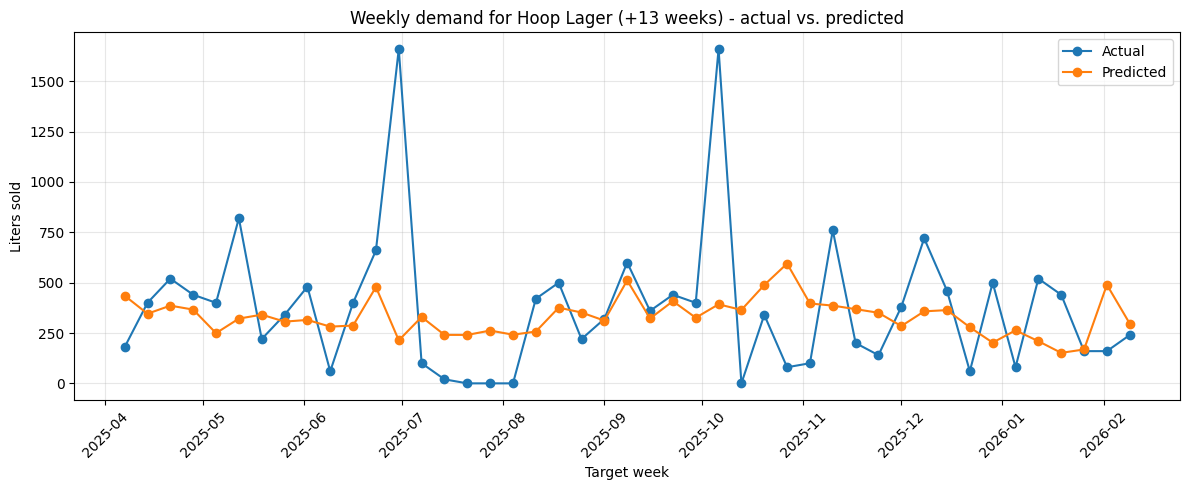

In [59]:
# Plot weekly actual vs predicted for the target week (+HORIZON_WEEKS)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(results_weekly["target_week"], results_weekly["actual"], marker="o", linestyle="-", label="Actual")
plt.plot(results_weekly["target_week"], results_weekly["predicted"], marker="o", linestyle="-", label="Predicted")

plt.title(f"Weekly demand for {WEEK_TARGET_BEER} (+{HORIZON_WEEKS} weeks) - actual vs. predicted")
plt.xlabel("Target week")
plt.ylabel("Liters sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
# ==============================
# Forecast next 13 weeks for ALL beer+container and aggregate to next 3 months
# ==============================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

WEEK_FREQ = "W-MON"

def seasonal_terms_woy(week_of_year: int) -> tuple[float, float]:
    angle = 2 * np.pi * (week_of_year / 52.18)
    return float(np.sin(angle)), float(np.cos(angle))


def prepare_weekly_group(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("week").copy()
    group = group.drop_duplicates(subset=["week"], keep="last")

    full_weeks = pd.date_range(group["week"].min(), group["week"].max(), freq=WEEK_FREQ)
    group = group.set_index("week").reindex(full_weeks)
    group.index.name = "week"
    group = group.reset_index()

    group["liters"] = pd.to_numeric(group["liters"], errors="coerce").fillna(0.0).clip(lower=0.0)

    if "temp_mean" in group.columns:
        group["temp_mean"] = pd.to_numeric(group["temp_mean"], errors="coerce")
        group["temp_mean"] = group["temp_mean"].interpolate(limit_direction="both")
        group["temp_mean"] = group["temp_mean"].fillna(group["temp_mean"].mean())

    if "rain_mm" in group.columns:
        group["rain_mm"] = pd.to_numeric(group["rain_mm"], errors="coerce")
        group["rain_mm"] = group["rain_mm"].interpolate(limit_direction="both")
        group["rain_mm"] = group["rain_mm"].fillna(group["rain_mm"].mean())

    group["week_of_year"] = group["week"].dt.isocalendar().week.astype(int)
    group["month"] = group["week"].dt.month.astype(int)
    group["year"] = group["week"].dt.year.astype(int)
    group["time_index"] = np.arange(len(group), dtype=int)

    if "temp_mean" in group.columns:
        temp_thresh = float(np.nanquantile(group["temp_mean"], 0.75))
        group["hot_week"] = (group["temp_mean"] >= temp_thresh).astype(int)
    else:
        group["hot_week"] = 0

    if "rain_mm" in group.columns:
        rain_thresh = float(np.nanquantile(group["rain_mm"], 0.75))
        group["rainy_week"] = (group["rain_mm"] >= rain_thresh).astype(int)
    else:
        group["rainy_week"] = 0

    angle_w = 2 * np.pi * (group["week_of_year"] / 52.18)
    group["sin_woy"] = np.sin(angle_w)
    group["cos_woy"] = np.cos(angle_w)

    # Lags + rolling (past-only)
    WEEK_LAGS = [1, 2, 3, 4, 8, 12, 26]
    usable_week_lags = [lag for lag in WEEK_LAGS if lag < len(group)]
    for lag in usable_week_lags:
        group[f"lag_{lag}"] = group["liters"].shift(lag)

    group["roll_mean_4"] = group["liters"].shift(1).rolling(4, min_periods=1).mean()
    group["roll_mean_12"] = group["liters"].shift(1).rolling(12, min_periods=1).mean()
    group["roll_sum_4"] = group["liters"].shift(1).rolling(4, min_periods=1).sum()

    return group


def build_feature_cols(df: pd.DataFrame) -> list[str]:
    cols = [
        "time_index",
        "week_of_year",
        "month",
        "year",
        "sin_woy",
        "cos_woy",
        "roll_mean_4",
        "roll_mean_12",
        "roll_sum_4",
        "hot_week",
        "rainy_week",
    ]
    if "temp_mean" in df.columns:
        cols.append("temp_mean")
    if "rain_mm" in df.columns:
        cols.append("rain_mm")
    cols += [c for c in df.columns if c.startswith("lag_")]
    return cols


def fit_model(df: pd.DataFrame, feature_cols: list[str]) -> RandomForestRegressor:
    train = df.dropna(subset=feature_cols + ["liters"]).copy()
    X = train[feature_cols].values
    y = train["liters"].values

    model = RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=2,
    )
    model.fit(X, y)
    return model


def typical_weather_by_woy(df: pd.DataFrame) -> dict[int, dict[str, float]]:
    out: dict[int, dict[str, float]] = {}
    if ("temp_mean" not in df.columns) and ("rain_mm" not in df.columns):
        return out

    agg_dict = {}
    if "temp_mean" in df.columns:
        agg_dict["temp_mean"] = "mean"
    if "rain_mm" in df.columns:
        agg_dict["rain_mm"] = "mean"

    agg = df.groupby("week_of_year").agg(agg_dict)
    out = agg.to_dict(orient="index")
    return {int(k): {kk: float(vv) for kk, vv in v.items()} for k, v in out.items()}


def forecast_next_weeks(df_prepped: pd.DataFrame, beer: str, container: str, horizon_weeks: int) -> pd.DataFrame:
    feature_cols = build_feature_cols(df_prepped)
    model = fit_model(df_prepped, feature_cols)

    weather_lookup = typical_weather_by_woy(df_prepped)
    temp_thresh = float(np.nanquantile(df_prepped["temp_mean"], 0.75)) if "temp_mean" in df_prepped.columns else None
    rain_thresh = float(np.nanquantile(df_prepped["rain_mm"], 0.75)) if "rain_mm" in df_prepped.columns else None

    # history used for lags/rolls
    history = df_prepped["liters"].astype(float).tolist()
    last_week = pd.Timestamp(df_prepped["week"].max())

    lag_cols = [c for c in feature_cols if c.startswith("lag_")]
    usable_lags = sorted({int(c.split("_")[1]) for c in lag_cols})

    preds: list[dict] = []

    for step in range(1, horizon_weeks + 1):
        next_week = last_week + pd.Timedelta(weeks=1)
        woy = int(next_week.isocalendar().week)
        sin_woy, cos_woy = seasonal_terms_woy(woy)

        temp_mean = None
        rain_mm = None
        if weather_lookup:
            w = weather_lookup.get(woy, {})
            temp_mean = w.get("temp_mean")
            rain_mm = w.get("rain_mm")

        hot_week = int(temp_thresh is not None and temp_mean is not None and float(temp_mean) >= temp_thresh)
        rainy_week = int(rain_thresh is not None and rain_mm is not None and float(rain_mm) >= rain_thresh)

        row = {
            "time_index": int(df_prepped["time_index"].max()) + step,
            "week_of_year": woy,
            "month": int(next_week.month),
            "year": int(next_week.year),
            "sin_woy": sin_woy,
            "cos_woy": cos_woy,
            "hot_week": hot_week,
            "rainy_week": rainy_week,
            "roll_mean_4": float(np.mean(history[-4:])) if history else 0.0,
            "roll_mean_12": float(np.mean(history[-12:])) if history else 0.0,
            "roll_sum_4": float(np.sum(history[-4:])) if history else 0.0,
        }

        for lag in usable_lags:
            row[f"lag_{lag}"] = float(history[-lag]) if len(history) >= lag else 0.0

        if "temp_mean" in feature_cols:
            row["temp_mean"] = float(temp_mean) if temp_mean is not None else float(np.nanmean(df_prepped["temp_mean"]))
        if "rain_mm" in feature_cols:
            row["rain_mm"] = float(rain_mm) if rain_mm is not None else float(np.nanmean(df_prepped["rain_mm"]))

        X_new = pd.DataFrame([row], columns=feature_cols).fillna(0.0)
        pred = float(model.predict(X_new)[0])
        pred = max(0.0, pred)

        preds.append(
            {
                "week": next_week,
                "beer": beer,
                "container": container,
                "forecast_liters": pred,
            }
        )

        history.append(pred)
        last_week = next_week

    return pd.DataFrame(preds)


# Run forecasting for focus beers (all containers)
min_nonzero_weeks = 20

weekly_focus = weekly_df[weekly_df["beer"].isin(FOCUS_BEERS)].copy()

forecasts = []
for (beer, container), grp in weekly_focus.groupby(["beer", "container"]):
    g = grp.copy()
    if g["liters"].sum() <= 0:
        continue

    g_prep = prepare_weekly_group(g)
    if (g_prep["liters"] > 0).sum() < min_nonzero_weeks:
        continue

    fc = forecast_next_weeks(g_prep, beer, container, horizon_weeks=HORIZON_WEEKS)
    forecasts.append(fc)

forecast_weekly_all = pd.concat(forecasts, ignore_index=True) if forecasts else pd.DataFrame(columns=["week", "beer", "container", "forecast_liters"])

# Aggregate to months (next 3 calendar months)
forecast_weekly_all["month_start"] = forecast_weekly_all["week"].dt.to_period("M").dt.to_timestamp()
forecast_monthly_agg = (
    forecast_weekly_all
    .groupby(["month_start", "beer", "container"], as_index=False)["forecast_liters"].sum()
)

# Keep only the next 3 months from the first forecast week
if not forecast_weekly_all.empty:
    first_forecast_week = forecast_weekly_all["week"].min()
    start_month = first_forecast_week.to_period("M").to_timestamp()
    next_3_months = pd.date_range(start_month, periods=3, freq="MS")
    forecast_monthly_agg = forecast_monthly_agg[forecast_monthly_agg["month_start"].isin(next_3_months)].copy()

# Totals over the whole 13-week horizon
forecast_totals_13w = (
    forecast_weekly_all
    .groupby(["beer", "container"], as_index=False)["forecast_liters"].sum()
    .rename(columns={"forecast_liters": "forecast_total_next_13w"})
    .sort_values("forecast_total_next_13w", ascending=False)
)

print("Forecasted series:", forecast_totals_13w.shape[0])
display(forecast_totals_13w.head(10))

display(forecast_monthly_agg.sort_values(["month_start", "forecast_liters"], ascending=[True, False]).head(15))

# Save outputs
forecast_weekly_all.to_csv("data/processed/forecast_next_13w_weekly.csv", index=False)
forecast_monthly_agg.to_csv("data/processed/forecast_next_3mo_monthly_from_weekly.csv", index=False)
forecast_totals_13w.to_csv("data/processed/forecast_totals_next_13w.csv", index=False)

print("Saved:")
print("- data/processed/forecast_next_13w_weekly.csv")
print("- data/processed/forecast_next_3mo_monthly_from_weekly.csv")
print("- data/processed/forecast_totals_next_13w.csv")

/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/ven

Forecasted series: 12


/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/Users/Constantinvonkrogh/Desktop/GitHub/Beer_Brewery_PM/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


,beer,container,forecast_total_next_13w
9,Hoop Lager,Keg 20L,4891.558452
3,Hoop Bleke Nelis,Keg 20L,2690.904828
6,Hoop Kaper Tropical IPA,Keg 20L,1139.909455
0,Hoop Bleke Nelis,Bottle 33cl,1107.325020
10,Hoop Lager,Keg 50L,871.703406
2,Hoop Bleke Nelis,Can 33cl,568.077788
5,Hoop Kaper Tropical IPA,Bottle 33cl,567.366887
4,Hoop Bleke Nelis,Other,257.594071
11,Hoop Lager,Other,90.566846
8,Hoop Lager,Bottle 33cl,88.411363


,month_start,beer,container,forecast_liters
9,2026-02-01,Hoop Lager,Keg 20L,636.334934
3,2026-02-01,Hoop Bleke Nelis,Keg 20L,280.719167
6,2026-02-01,Hoop Kaper Tropical IPA,Keg 20L,127.619537
2,2026-02-01,Hoop Bleke Nelis,Can 33cl,97.169946
0,2026-02-01,Hoop Bleke Nelis,Bottle 33cl,95.514891
5,2026-02-01,Hoop Kaper Tropical IPA,Bottle 33cl,71.795363
4,2026-02-01,Hoop Bleke Nelis,Other,35.837621
11,2026-02-01,Hoop Lager,Other,7.648934
7,2026-02-01,Hoop Kaper Tropical IPA,Other,7.079134
1,2026-02-01,Hoop Bleke Nelis,Bottle 75cl,4.210500


Saved:
- data/processed/forecast_next_13w_weekly.csv
- data/processed/forecast_next_3mo_monthly_from_weekly.csv
- data/processed/forecast_totals_next_13w.csv


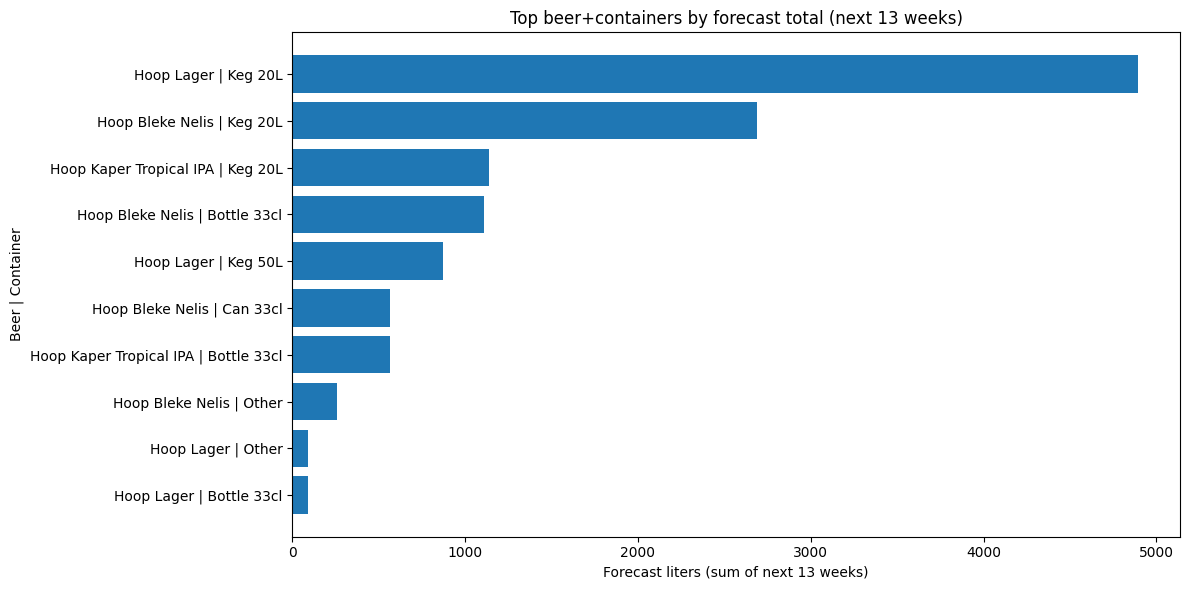

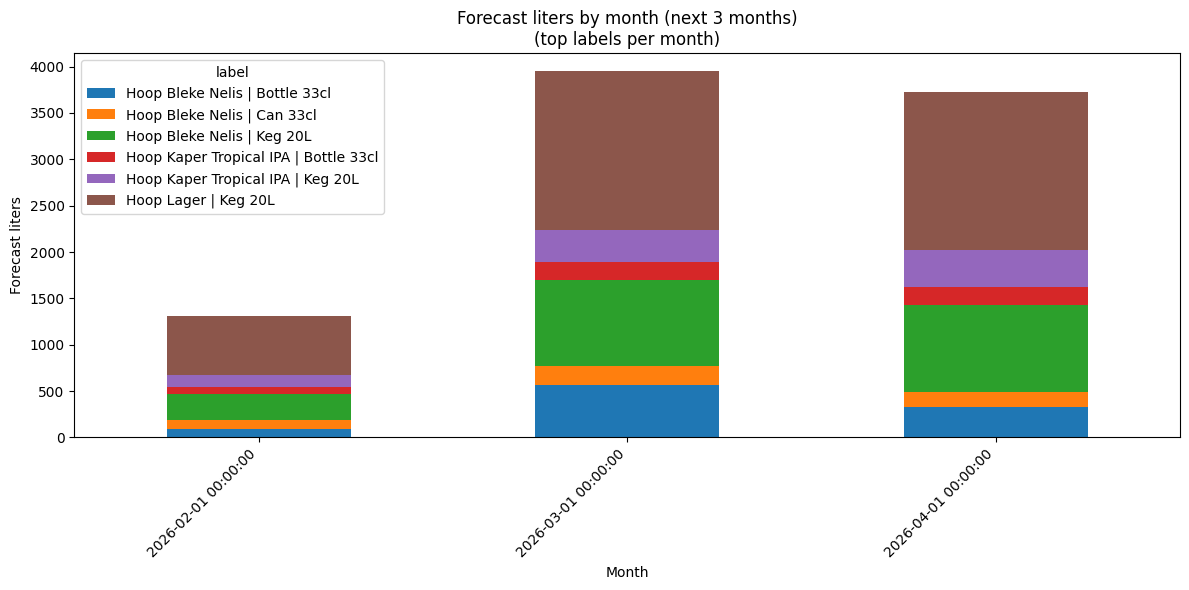

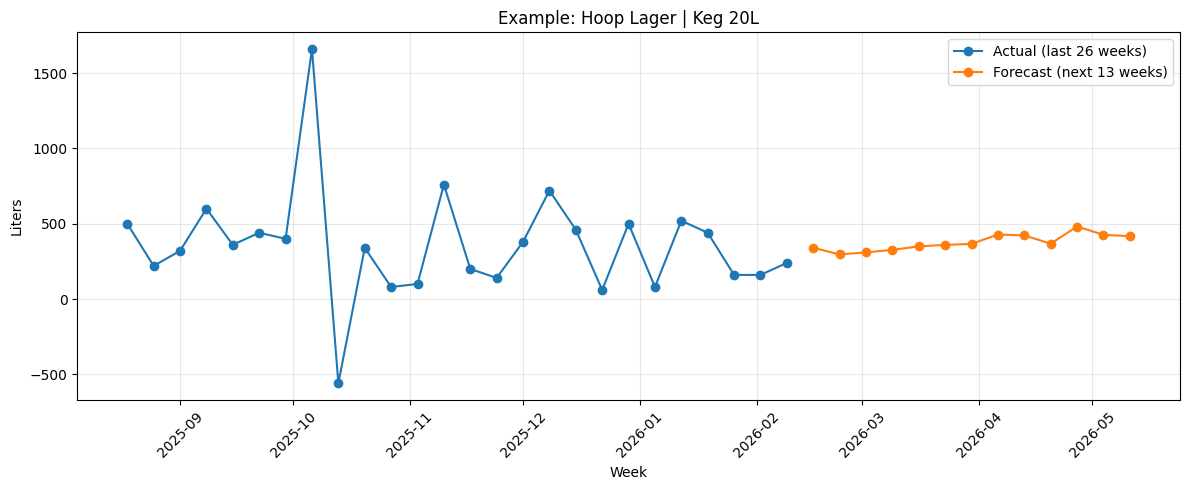

In [61]:
# ==============================
# Graphs: top beer+containers + example series (actual recent vs forecast)
# ==============================

import matplotlib.pyplot as plt

# 1) Top 10 beer+container by total forecast in next 13 weeks
if not forecast_totals_13w.empty:
    top_n = 10
    top = forecast_totals_13w.head(top_n).copy()
    top["label"] = top["beer"] + " | " + top["container"]

    plt.figure(figsize=(12, 6))
    plt.barh(top["label"][::-1], top["forecast_total_next_13w"][::-1])
    plt.title("Top beer+containers by forecast total (next 13 weeks)")
    plt.xlabel("Forecast liters (sum of next 13 weeks)")
    plt.ylabel("Beer | Container")
    plt.tight_layout()
    plt.show()

# 2) Next 3 months totals (stacked by beer+container, show top 6 per month)
if not forecast_monthly_agg.empty:
    tmp = forecast_monthly_agg.copy()
    tmp["label"] = tmp["beer"] + " | " + tmp["container"]

    # limit clutter: keep top 6 labels per month
    keep_labels = set(
        tmp.sort_values(["month_start", "forecast_liters"], ascending=[True, False])
           .groupby("month_start")
           .head(6)["label"].unique()
    )
    tmp = tmp[tmp["label"].isin(keep_labels)].copy()

    pivot = tmp.pivot_table(index="month_start", columns="label", values="forecast_liters", aggfunc="sum").fillna(0.0)

    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_title("Forecast liters by month (next 3 months)\n(top labels per month)")
    ax.set_xlabel("Month")
    ax.set_ylabel("Forecast liters")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 3) Example series: last 26 actual weeks vs next 13 forecast
EXAMPLE_BEER = "Hoop Lager"
EXAMPLE_CONTAINER = "Keg 20L"

example_hist = weekly_df[(weekly_df["beer"] == EXAMPLE_BEER) & (weekly_df["container"] == EXAMPLE_CONTAINER)].copy()
example_hist = example_hist.sort_values("week")

example_fc = forecast_weekly_all[(forecast_weekly_all["beer"] == EXAMPLE_BEER) & (forecast_weekly_all["container"] == EXAMPLE_CONTAINER)].copy()
example_fc = example_fc.sort_values("week")

if not example_hist.empty and not example_fc.empty:
    last_hist = example_hist.tail(26)

    plt.figure(figsize=(12, 5))
    plt.plot(last_hist["week"], last_hist["liters"], marker="o", label="Actual (last 26 weeks)")
    plt.plot(example_fc["week"], example_fc["forecast_liters"], marker="o", label="Forecast (next 13 weeks)")
    plt.title(f"Example: {EXAMPLE_BEER} | {EXAMPLE_CONTAINER}")
    plt.xlabel("Week")
    plt.ylabel("Liters")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Example series not available for plotting.")

In [62]:
# ==============================
# Backtest for the 3 focus beers (all containers): actual vs predicted (+13 weeks)
# ==============================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

WEEK_FREQ = "W-MON"


def prepare_weekly_group_for_backtest(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("week").copy()
    group = group.drop_duplicates(subset=["week"], keep="last")

    full_weeks = pd.date_range(group["week"].min(), group["week"].max(), freq=WEEK_FREQ)
    group = group.set_index("week").reindex(full_weeks)
    group.index.name = "week"
    group = group.reset_index().rename(columns={"index": "week"})

    group["liters"] = pd.to_numeric(group["liters"], errors="coerce").fillna(0.0).clip(lower=0.0)

    if "temp_mean" in group.columns:
        group["temp_mean"] = pd.to_numeric(group["temp_mean"], errors="coerce")
        group["temp_mean"] = group["temp_mean"].interpolate(limit_direction="both")
        group["temp_mean"] = group["temp_mean"].fillna(group["temp_mean"].mean())

    if "rain_mm" in group.columns:
        group["rain_mm"] = pd.to_numeric(group["rain_mm"], errors="coerce")
        group["rain_mm"] = group["rain_mm"].interpolate(limit_direction="both")
        group["rain_mm"] = group["rain_mm"].fillna(group["rain_mm"].mean())

    group["week_of_year"] = group["week"].dt.isocalendar().week.astype(int)
    group["month"] = group["week"].dt.month.astype(int)
    group["year"] = group["week"].dt.year.astype(int)
    group["time_index"] = np.arange(len(group), dtype=int)

    if "temp_mean" in group.columns:
        temp_thresh = float(np.nanquantile(group["temp_mean"], 0.75))
        group["hot_week"] = (group["temp_mean"] >= temp_thresh).astype(int)
    else:
        group["hot_week"] = 0

    if "rain_mm" in group.columns:
        rain_thresh = float(np.nanquantile(group["rain_mm"], 0.75))
        group["rainy_week"] = (group["rain_mm"] >= rain_thresh).astype(int)
    else:
        group["rainy_week"] = 0

    angle_w = 2 * np.pi * (group["week_of_year"] / 52.18)
    group["sin_woy"] = np.sin(angle_w)
    group["cos_woy"] = np.cos(angle_w)

    WEEK_LAGS = [1, 2, 3, 4, 8, 12, 26]
    usable_week_lags = [lag for lag in WEEK_LAGS if lag < len(group)]
    for lag in usable_week_lags:
        group[f"lag_{lag}"] = group["liters"].shift(lag)

    group["roll_mean_4"] = group["liters"].shift(1).rolling(4, min_periods=1).mean()
    group["roll_mean_12"] = group["liters"].shift(1).rolling(12, min_periods=1).mean()
    group["roll_sum_4"] = group["liters"].shift(1).rolling(4, min_periods=1).sum()

    group["y_future"] = group["liters"].shift(-HORIZON_WEEKS)

    return group


def weekly_feature_columns(df: pd.DataFrame) -> list[str]:
    cols = [
        "time_index",
        "week_of_year",
        "month",
        "year",
        "sin_woy",
        "cos_woy",
        "roll_mean_4",
        "roll_mean_12",
        "roll_sum_4",
        "hot_week",
        "rainy_week",
    ]
    if "temp_mean" in df.columns:
        cols.append("temp_mean")
    if "rain_mm" in df.columns:
        cols.append("rain_mm")
    cols += [c for c in df.columns if c.startswith("lag_")]
    return cols


bt_rows = []
bt_preds = []

weekly_focus = weekly_df[weekly_df["beer"].isin(FOCUS_BEERS)].copy()

for (beer, container), grp in weekly_focus.groupby(["beer", "container"]):
    if grp["liters"].sum() <= 0:
        continue

    g = prepare_weekly_group_for_backtest(grp)
    feat_cols = weekly_feature_columns(g)

    df_m = g.dropna(subset=feat_cols + ["y_future"]).copy()
    if len(df_m) < 120:
        # too little history after lags+horizon
        continue

    X = df_m[feat_cols].values
    y = df_m["y_future"].values

    # hold out last 52 predictions
    test_size = min(52, max(26, len(df_m) // 4))
    split_idx = len(df_m) - test_size

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    model = RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=2,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae = float(mean_absolute_error(y_test, y_pred))

    bt_rows.append(
        {
            "beer": beer,
            "container": container,
            "n_rows": int(len(df_m)),
            "test_weeks": int(test_size),
            "rmse": rmse,
            "mae": mae,
        }
    )

    df_pred = pd.DataFrame(
        {
            "beer": beer,
            "container": container,
            "pred_week": df_m["week"].iloc[split_idx:].values,
            "target_week": (df_m["week"].iloc[split_idx:] + pd.to_timedelta(HORIZON_WEEKS, unit="W")).values,
            "actual": y_test,
            "predicted": y_pred,
        }
    )
    bt_preds.append(df_pred)

backtest_scores = pd.DataFrame(bt_rows).sort_values(["beer", "mae"]).reset_index(drop=True)
backtest_predictions = pd.concat(bt_preds, ignore_index=True) if bt_preds else pd.DataFrame(
    columns=["beer", "container", "pred_week", "target_week", "actual", "predicted"]
)

print("Backtested series (beer+container):", backtest_scores.shape[0])
display(backtest_scores)

Backtested series (beer+container): 15


,beer,container,n_rows,test_weeks,rmse,mae
0,Hoop Bleke Nelis,Keg 50L,182,45,63.245553,13.333333
1,Hoop Bleke Nelis,Can 33cl,182,45,45.143228,14.784000
2,Hoop Bleke Nelis,Other,182,45,38.063818,29.444597
3,Hoop Bleke Nelis,Bottle 75cl,182,45,59.521026,34.782273
4,Hoop Bleke Nelis,Bottle 33cl,182,45,76.455453,63.944338
5,Hoop Bleke Nelis,Keg 20L,182,45,127.138788,89.370864
6,Hoop Kaper Tropical IPA,Other,182,45,12.001457,9.063176
7,Hoop Kaper Tropical IPA,Can 33cl,182,45,34.575540,22.076531
8,Hoop Kaper Tropical IPA,Bottle 33cl,182,45,37.617920,28.816582
9,Hoop Kaper Tropical IPA,Keg 20L,182,45,106.244976,79.433855


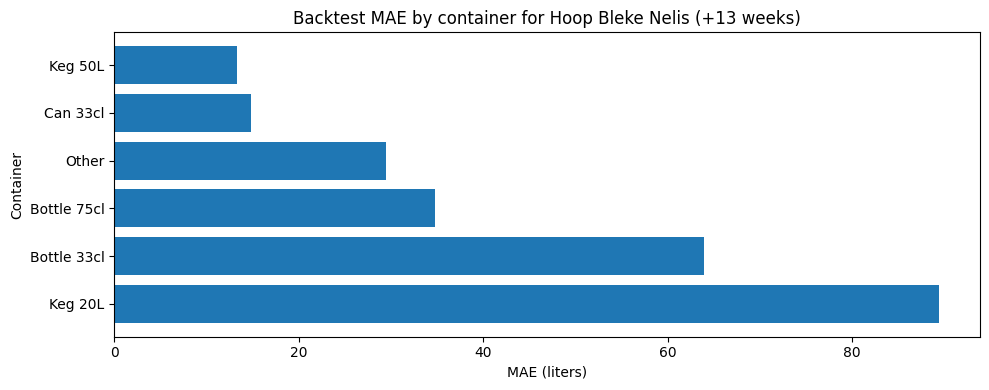

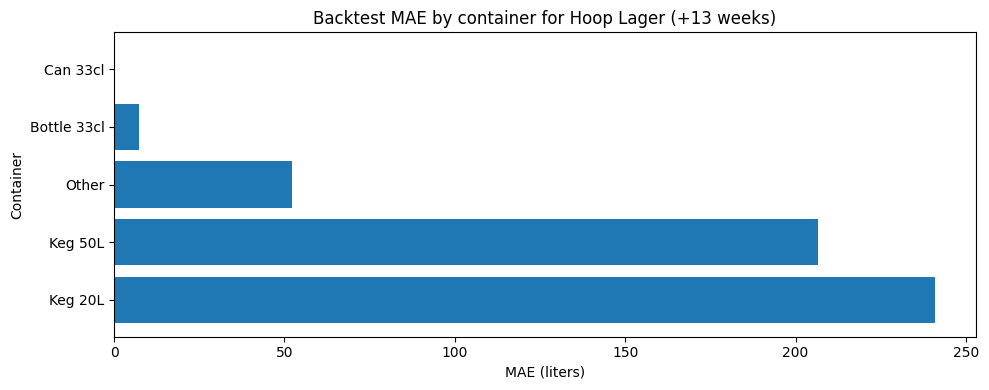

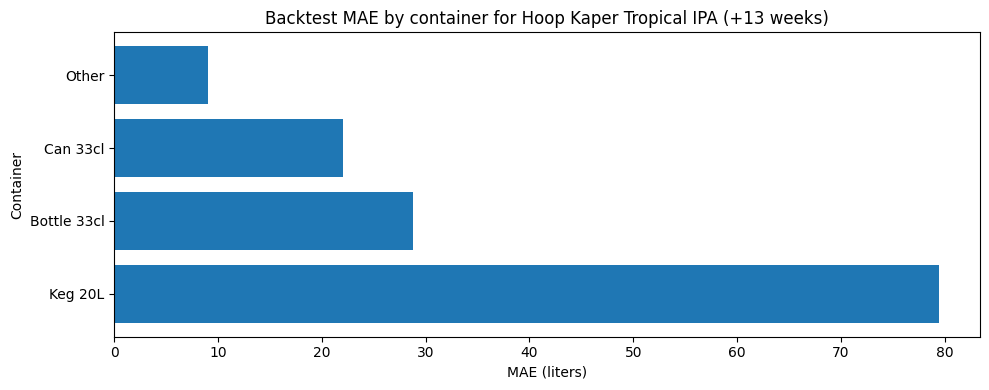

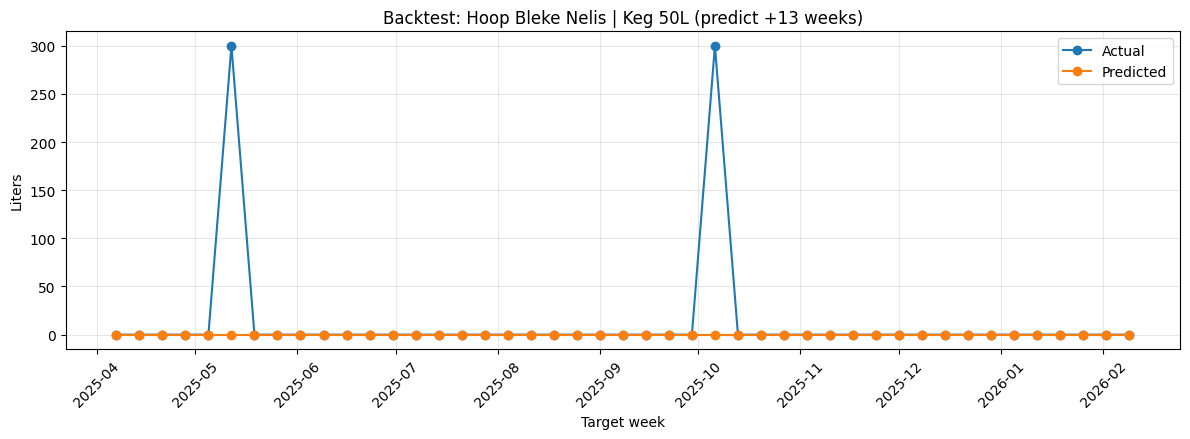

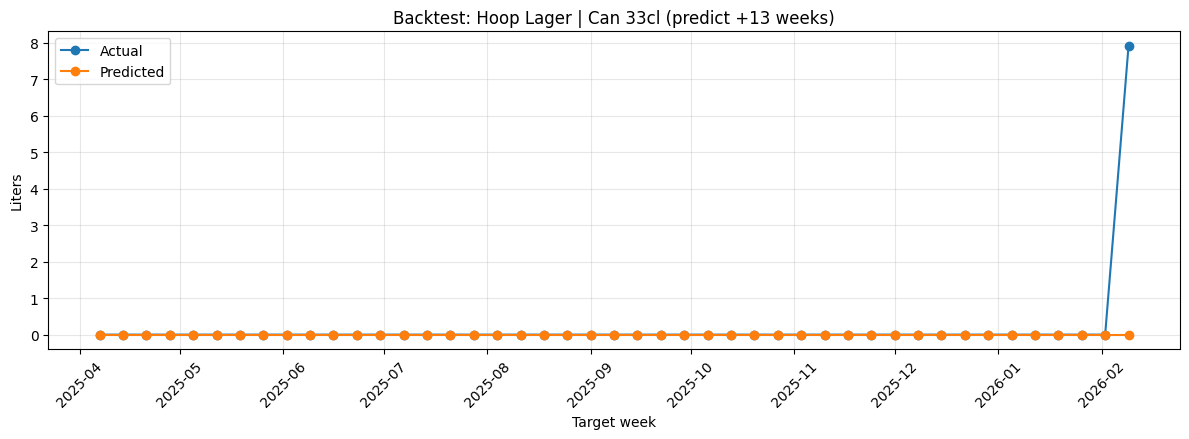

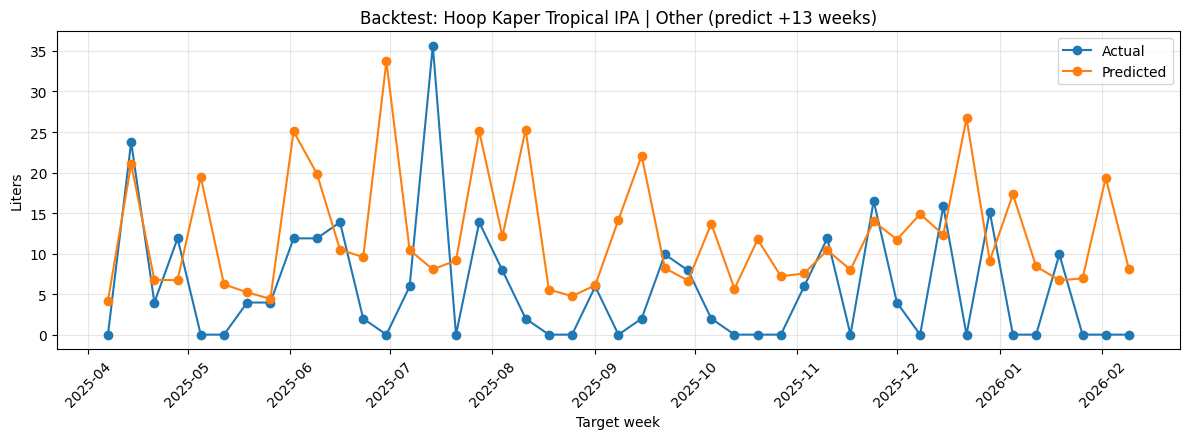

In [63]:
# ==============================
# Graphs: backtest (actual vs predicted) for each focus beer
# ==============================

import matplotlib.pyplot as plt

if backtest_predictions.empty:
    raise ValueError("No backtest predictions were produced (maybe not enough history after lags+horizon).")

# Summary bar chart: MAE per container within each beer
for beer in FOCUS_BEERS:
    s = backtest_scores[backtest_scores["beer"] == beer].copy()
    if s.empty:
        continue
    s = s.sort_values("mae").head(10)
    s["label"] = s["container"]

    plt.figure(figsize=(10, 4))
    plt.barh(s["label"][::-1], s["mae"][::-1])
    plt.title(f"Backtest MAE by container for {beer} (+{HORIZON_WEEKS} weeks)")
    plt.xlabel("MAE (liters)")
    plt.ylabel("Container")
    plt.tight_layout()
    plt.show()

# Line plots: pick the BEST container per beer (lowest MAE)
for beer in FOCUS_BEERS:
    best = backtest_scores[backtest_scores["beer"] == beer].sort_values("mae").head(1)
    if best.empty:
        print(f"No backtest series for {beer}.")
        continue
    container = best["container"].iloc[0]

    dfp = backtest_predictions[(backtest_predictions["beer"] == beer) & (backtest_predictions["container"] == container)].copy()
    dfp = dfp.sort_values("target_week")

    plt.figure(figsize=(12, 4.5))
    plt.plot(dfp["target_week"], dfp["actual"], marker="o", linewidth=1.5, label="Actual")
    plt.plot(dfp["target_week"], dfp["predicted"], marker="o", linewidth=1.5, label="Predicted")
    plt.title(f"Backtest: {beer} | {container} (predict +{HORIZON_WEEKS} weeks)")
    plt.xlabel("Target week")
    plt.ylabel("Liters")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [64]:
# ==============================
# Weekly spike classification for focus beers ("will there be a spike in +13 weeks?")
# ==============================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

SPIKE_QUANTILE = 0.80  # top 20% weeks = spike

spike_rows = []
spike_preds_all = []

# Reuse the same prepared weekly groups & feature columns as the +13w regression backtest
weekly_focus = weekly_df[weekly_df["beer"].isin(FOCUS_BEERS)].copy()

for (beer, container), grp in weekly_focus.groupby(["beer", "container"]):
    if grp["liters"].sum() <= 0:
        continue

    g = prepare_weekly_group_for_backtest(grp)
    feat_cols = weekly_feature_columns(g)

    # Label spikes for THIS series: weeks with liters above 80th percentile
    if g["liters"].sum() <= 0:
        continue
    spike_threshold = float(np.nanquantile(g["liters"], SPIKE_QUANTILE))
    g["is_spike_now"] = (g["liters"] >= spike_threshold).astype(int)

    # Target: spike status HORIZON_WEEKS into the future
    g["is_spike_future"] = g["is_spike_now"].shift(-HORIZON_WEEKS)

    df_m = g.dropna(subset=feat_cols + ["is_spike_future"]).copy()
    if len(df_m) < 120:
        # too little history after lags+horizon
        continue

    # Need some positive spikes in the future target to learn anything
    if int(df_m["is_spike_future"].sum()) < 5:
        continue

    X = df_m[feat_cols].values
    y_cls = df_m["is_spike_future"].astype(int).values

    # Time-based split: hold out the last ~1/4 (between 26 and 52 weeks)
    test_size = min(52, max(26, len(df_m) // 4))
    split_idx = len(df_m) - test_size

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y_cls[:split_idx], y_cls[split_idx:]

    # If train or test is empty, or only a single class in train, skip this series
    if len(X_train) == 0 or len(X_test) == 0:
        continue
    if np.unique(y_train).size < 2:
        # classifier can't learn if only spike or only non-spike in train
        continue

    pred_week = df_m["week"]
    target_week = pred_week + pd.to_timedelta(HORIZON_WEEKS, unit="W")
    target_week_test = target_week.iloc[split_idx:]

    clf = RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
    )
    clf.fit(X_train, y_train)

    y_proba = clf.predict_proba(X_test)[:, 1]
    # Use threshold tuned slightly low to catch more spikes
    y_pred = (y_proba >= 0.4).astype(int)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    spike_rows.append(
        {
            "beer": beer,
            "container": container,
            "n_rows": int(len(df_m)),
            "test_weeks": int(test_size),
            "spike_threshold_liters": spike_threshold,
            "spike_count_test": int(y_test.sum()),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
        }
    )

    df_pred = pd.DataFrame(
        {
            "beer": beer,
            "container": container,
            "target_week": target_week_test.values,
            "actual_spike": y_test,
            "pred_spike": y_pred,
            "spike_proba": y_proba,
        }
    )
    spike_preds_all.append(df_pred)

if spike_rows:
    spike_scores = (
        pd.DataFrame(spike_rows)
        .sort_values(["beer", "recall", "precision"], ascending=[True, False, False])
        .reset_index(drop=True)
    )
else:
    spike_scores = pd.DataFrame(
        columns=[
            "beer",
            "container",
            "n_rows",
            "test_weeks",
            "spike_threshold_liters",
            "spike_count_test",
            "precision",
            "recall",
            "f1",
            "tp",
            "fp",
            "fn",
            "tn",
        ]
    )

spike_predictions = (
    pd.concat(spike_preds_all, ignore_index=True)
    if spike_preds_all
    else pd.DataFrame(
        columns=[
            "beer",
            "container",
            "target_week",
            "actual_spike",
            "pred_spike",
            "spike_proba",
        ]
    )
)

print("Spike classifier series (beer+container):", spike_scores.shape[0])
if not spike_scores.empty:
    display(spike_scores.head(15))
else:
    print("No series had enough history/spikes to train a classifier.")

print("\nExample spike predictions (first 20 rows):")
if not spike_predictions.empty:
    display(spike_predictions.head(20))
else:
    print("No spike predictions available.")


Spike classifier series (beer+container): 9


,beer,container,n_rows,test_weeks,spike_threshold_liters,spike_count_test,precision,recall,f1,tp,fp,fn,tn
0,Hoop Bleke Nelis,Bottle 75cl,182,45,9.00,5,0.086957,0.400000,0.142857,2,21,3,19
1,Hoop Bleke Nelis,Other,182,45,51.81,6,0.500000,0.166667,0.250000,1,1,5,38
2,Hoop Bleke Nelis,Keg 20L,182,45,260.00,12,1.000000,0.083333,0.153846,1,0,11,33
3,Hoop Bleke Nelis,Bottle 33cl,182,45,126.72,4,0.000000,0.000000,0.000000,0,0,4,41
4,Hoop Kaper Tropical IPA,Keg 20L,182,45,120.00,17,0.272727,0.176471,0.214286,3,8,14,20
5,Hoop Kaper Tropical IPA,Bottle 33cl,182,45,47.52,23,0.800000,0.173913,0.285714,4,1,19,21
6,Hoop Kaper Tropical IPA,Other,182,45,19.80,2,0.000000,0.000000,0.000000,0,2,2,41
7,Hoop Lager,Other,182,45,4.95,11,0.270270,0.909091,0.416667,10,27,1,7
8,Hoop Lager,Keg 20L,182,45,340.00,25,0.500000,0.120000,0.193548,3,3,22,17



Example spike predictions (first 20 rows):


,beer,container,target_week,actual_spike,pred_spike,spike_proba
0,Hoop Bleke Nelis,Bottle 33cl,2025-04-07,0,0,0.203899
1,Hoop Bleke Nelis,Bottle 33cl,2025-04-14,0,0,0.323261
2,Hoop Bleke Nelis,Bottle 33cl,2025-04-21,0,0,0.162511
3,Hoop Bleke Nelis,Bottle 33cl,2025-04-28,1,0,0.127791
4,Hoop Bleke Nelis,Bottle 33cl,2025-05-05,0,0,0.125712
5,Hoop Bleke Nelis,Bottle 33cl,2025-05-12,0,0,0.173267
6,Hoop Bleke Nelis,Bottle 33cl,2025-05-19,0,0,0.126928
7,Hoop Bleke Nelis,Bottle 33cl,2025-05-26,0,0,0.114196
8,Hoop Bleke Nelis,Bottle 33cl,2025-06-02,0,0,0.144363
9,Hoop Bleke Nelis,Bottle 33cl,2025-06-09,0,0,0.121139


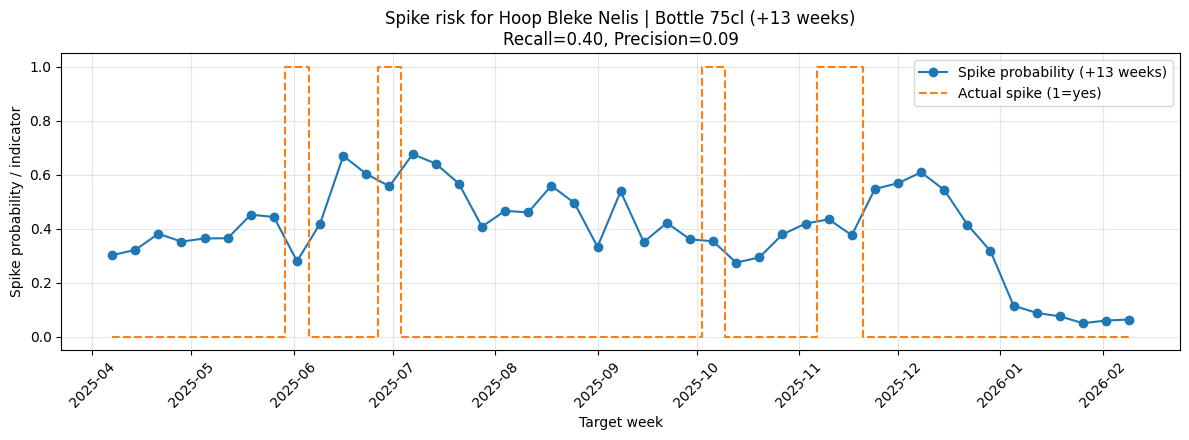

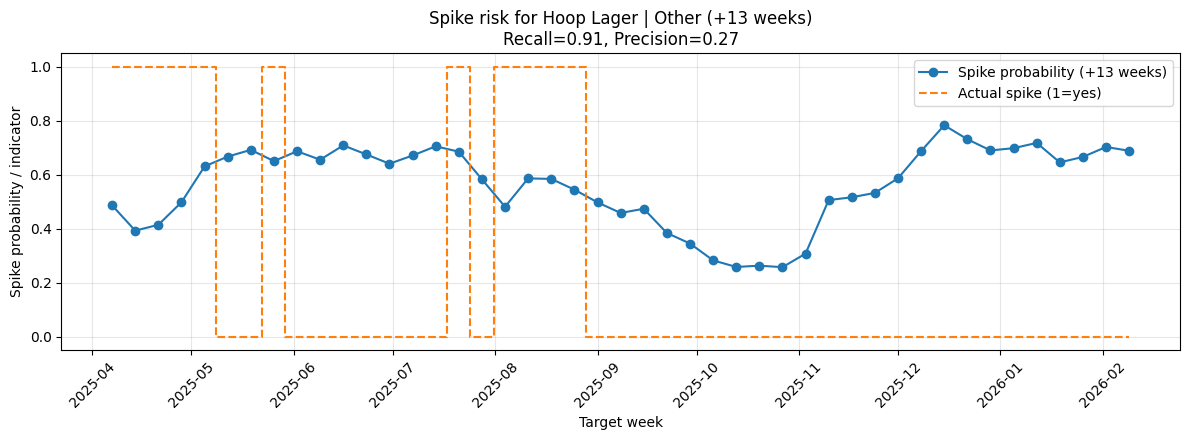

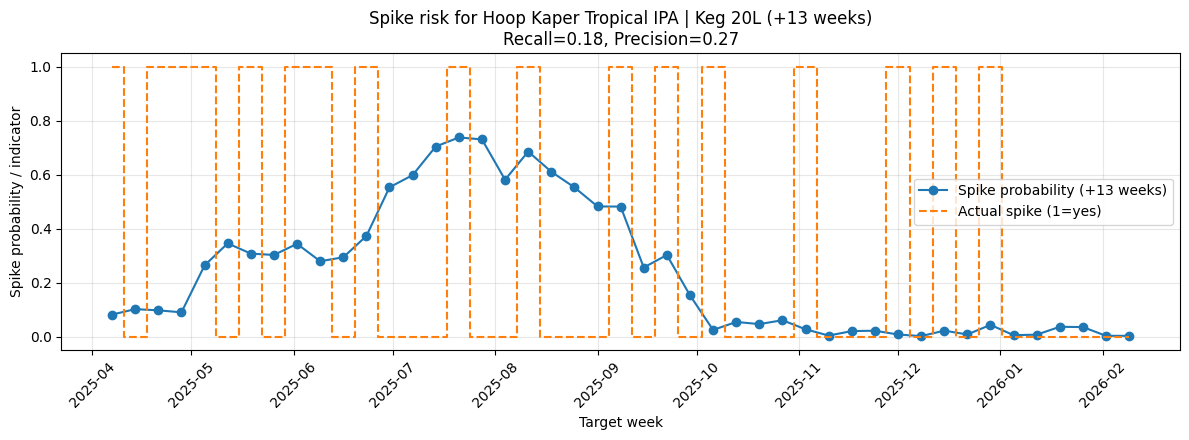

In [65]:
# ==============================
# Graphs: spike probability vs actual spikes for best container per focus beer
# ==============================

import matplotlib.pyplot as plt

if spike_predictions.empty:
    raise ValueError("No spike predictions were produced (maybe not enough history). Run previous cells first.")

# For each focus beer, pick the container with highest spike recall
for beer in FOCUS_BEERS:
    best = spike_scores[spike_scores["beer"] == beer].sort_values(
        ["recall", "precision"], ascending=[False, False]
    ).head(1)
    if best.empty:
        print(f"No spike classifier series for {beer}.")
        continue

    container = best["container"].iloc[0]
    rec = best["recall"].iloc[0]
    prec = best["precision"].iloc[0]

    dfp = spike_predictions[
        (spike_predictions["beer"] == beer)
        & (spike_predictions["container"] == container)
    ].copy()
    dfp = dfp.sort_values("target_week")

    if dfp.empty:
        print(f"No spike predictions for {beer} | {container}.")
        continue

    plt.figure(figsize=(12, 4.5))
    plt.plot(
        dfp["target_week"],
        dfp["spike_proba"],
        marker="o",
        linestyle="-",
        label="Spike probability (+13 weeks)",
    )

    # Actual spikes as 0/1 line
    plt.step(
        dfp["target_week"],
        dfp["actual_spike"],
        where="mid",
        linestyle="--",
        color="C1",
        label="Actual spike (1=yes)",
    )

    plt.title(
        f"Spike risk for {beer} | {container} (+{HORIZON_WEEKS} weeks)\n"
        f"Recall={rec:.2f}, Precision={prec:.2f}"
    )
    plt.xlabel("Target week")
    plt.ylabel("Spike probability / indicator")
    plt.ylim(-0.05, 1.05)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()